# IG visualizations

Sample 3 true positives and 3 true negatives directly from `tests/test_IG_output.jsonl`, then render the top-abundance tokens for each sample.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd() / "src"))

from token_source_attributor.visualization import display_random_tp_tn_token_charts, display_random_monotonic_abundance_token_charts, display_global_species_signal_summary


In [3]:
# data inspection
'''
"# data inspection\n",
are there positive and negative gradients or only positive? (is there sign to this signal?
what is the mean, median, variance and mode of the IG gradients
Answers:
If abundance is 0, the gradient IS 0.

The species gradients are always 0. Since the model is Fixed Slot Attention, sequence length is an identical 1662 species vector in every sample, leading to the same exact deterministic species embedding for each sample.

The degree of abundance becomes the only sample signal provided by the data to the classifier. The species embeddings are provided by MLM pretraining.

*show them in k-mean with the species embedddings to prove they are learned


if there is sign does it mean that > 0 are drivers toward disease and < 0 are drivers toward health based on the log-odds target logit?
Yes.

[CLS] attention can tell you that this species abundance token is important but it cannot tell you why.

Integrated gradients can tell you its important and can tell you whether it leads to the diagnoses or away from it (signed gradients).
It can tease causation out of the model ether.

7382 samples

stats for all IG atributions
len:  12267222
mean -0.0011763345995437695
median 0.0
variance:  0.0663922222798484
range:  [-32.77887725830078, 36.831268310546875])

stats for IG atrributions with abundance 0
len:  11770398
mean 0.0
median 0.0
variance:  0.0
range:  [0.0, 0.0])

stats for IG atrributions with TP
len:  5665758
mean 0.002776577763198292
median 0.0
variance:  0.06383470980751133
range:  [-32.77887725830078, 23.896650314331055])


stats for IG atrributions with TN
len:  6601464
mean -0.004568952485895151
median 0.0
variance:  0.06856230674236866
range:  [-30.25447654724121, 36.831268310546875])




what is the mean median, variance and mode of all abundance scores?

stats for all abundance_scores
len:  12267222
mean 1.1133660905460094
median 0.0
mode 0
variance:  37.76271956695957
range:  [0, 50])

Abundance scores on TP samples:
stats for abundance_scores
len:  5665758
mean 0.9204831904221819
median 0.0
mode 0
variance:  31.42428089028839
range:  [0, 50])

Abundance scores on TN samples:
stats for abundance_scores
len:  6601464
mean 1.2789093449574216
median 0.0
mode 0
variance:  43.14339899830871
range:  [0, 50])

  
what is the mean median, mode and variance of the attention scores... should be bounded [0,1]
is attention being paid to tokens of 0 abundance? Yes, about an order of magnitude less than non zero abundance tokens.

stats for all attention_scores (Samples * vocab)
len:  12267222
mean 0.0006014432357802775
median 0.00030778421205468476
variance:  5.844569225386607e-06
range:  [7.09273517713882e-05, 0.222137451171875])

stats for attention scores on samples with 0 abundance 
len:  11770398
mean 0.00031654220391060515
median 0.00030326533305924386
variance:  1.245180729259016e-07
range:  [7.09273517713882e-05, 0.022158058360219002])

stats for attention scores on TP samples
len:  5665758
mean 0.000601446242652556
median 0.00034440589661244303
variance:  5.397691897813847e-06
range:  [8.064694702625275e-05, 0.20840618014335632])

stats for attention scores on TN samples
len:  6601464
mean 0.0006014406551086769
median 0.000268495234195143
variance:  6.22810517947479e-06
range:  [7.09273517713882e-05, 0.222137451171875])

'''
import json
from pathlib import Path

def load_samples(jsonl_path: str | Path) -> list[dict]:
    samples = []
    with Path(jsonl_path).open(encoding="utf-8") as jsonl_file:
        for line in jsonl_file:
            line = line.strip()
            if not line:
                continue

            record = json.loads(line)
            if record.get("record_type") == "batch":
                samples.extend(record.get("samples", []))
            else:
                samples.append(record)

    return samples

samples = load_samples("tests/test_IG_output.jsonl")
len(samples), samples[0].keys()


(7382, dict_keys(['record_type', 'dataset_path', 'checkpoint_path']))

In [87]:
'''
{'sample_number': 0,
 'sample_id': 'MV_FEI2_t1Q14',
 'study_id': '2021-03-31.AsnicarF_2017.relative_abundance',
 'disease': 'healthy',
 'label': 0,
 'pred': 0,
 'prediction_type': 'true_negative',
 'prob_healthy': 0.9992167949676514,
 'prob_ibd': 0.0007832193514332175,
 'confidence': 0.9992167949676514,
 'entropy': 0.006384559441357851,
 'tokens': [{'token_index': 0,
   'species_id': 0,
   'abundance_bin': 0,
   'ig_species': 0.0,
   'ig_abundance': 0.0,
   'ig_species_plus_abundance': 0.0,
   'cls_score': 0.0003602262295316905},
  {'token_index': 1,
   'species_id': 1,
   'abundance_bin': 0,
   'ig_species': 0.0,
   'ig_abundance': 0.0,
   'ig_species_plus_abundance': 0.0,
   'cls_score': 0.0004316550912335515},
'''
import numpy as np
meta, study_samples = samples[0],samples[1:]

sample_abundances = []
sample_attentions = []
sample_ig = []

attention_on_zero_abundances = []
for sample in study_samples:
    attention_scores = []
    sample_ig_scores = []
    if sample['prediction_type'] == 'true_negative':
        for token in sample['tokens']:
            assert token['ig_abundance'] == token['ig_species_plus_abundance']
            # if token['abundance_bin'] == 0:
            sample_ig.append(token['ig_abundance'])
            sample_attentions.append(token["cls_score"])
            sample_abundances.append(token['abundance_bin'])
            
    
    # sample_ig.append(sample_ig_scores)
    # sample_attentions.append(attention_scores)
        
abundance_scores = np.array(sample_abundances)
sample_attentions_np = np.array(sample_attentions)
sample_ig_np = np.array(sample_ig)
print('abundance scores', abundance_scores.shape[0])
print('sample attentions', sample_attentions_np.shape[0], 'len sample scores, sample_attentions_np.shape[1]')
print('sample igs ', sample_ig_np.shape[0], 'len sample scores , sample_ig_np.shape[1]')


            


abundance scores 6601464
sample attentions 6601464 len sample scores, sample_attentions_np.shape[1]
sample igs  6601464 len sample scores , sample_ig_np.shape[1]


In [88]:
def get_stats(np_array, name):
    print(f'stats for {name}')
    print('len: ', np.size(np_array))
    print(f'mean', np_array.mean())
    print(f'median', np.median(np_array))
    try:
        print(f'mode', np.bincount(np_array).argmax())
    except Exception:
        print('could not compute bincount')
    print(f'variance: ', np.var(np_array))
    print('range: ', f'[{np.min(np_array)}, {np.max(np_array)}])')
    
get_stats(abundance_scores, 'abundance_scores')
get_stats(sample_attentions_np, 'attention_scores')
get_stats(sample_ig_np, 'sample ig scores')

stats for abundance_scores
len:  6601464
mean 1.2789093449574216
median 0.0
mode 0
variance:  43.14339899830871
range:  [0, 50])
stats for attention_scores
len:  6601464
mean 0.0006014406551086769
median 0.000268495234195143
could not compute bincount
variance:  6.22810517947479e-06
range:  [7.09273517713882e-05, 0.222137451171875])
stats for sample ig scores
len:  6601464
mean -0.004568952485895151
median 0.0
could not compute bincount
variance:  0.06856230674236866
range:  [-30.25447654724121, 36.831268310546875])


stats for attention_scores
len:  7381
mean 0.0006014432357802775
median 0.00030778421205468476
variance:  5.844569225386607e-06
range:  [7.09273517713882e-05, 0.222137451171875])


In [ ]:
display_random_tp_tn_token_charts(
    jsonl_path="tests/test_IG_output.jsonl",
    species_vocab_path="src/token_source_attributor/data/species_vocab.txt",
    samples_per_class=3,
    top_k=10,
    seed=7,
)

# maybe give more importance to visualizing items with lower abundance but higher IG?
# are there IG given to 0 abundance?

# you can add up the scores below if the sum > 0, model predicts IBD, if < 0 model predicts healthy
#YES!
# model accuracy is 93% for IBD
# 



{'true_positive': [{'batch_index': 196,
   'sample_number': 6300,
   'sample_id': 'HSMA33LH',
   'study_id': '2021-10-14.HMP_2019_ibdmdb.relative_abundance',
   'disease': 'IBD',
   'label': 1,
   'pred': 1,
   'prediction_type': 'true_positive',
   'prob_healthy': 0.0008286806405521929,
   'prob_ibd': 0.9991713762283325,
   'confidence': 0.9991713762283325,
   'entropy': 0.006708329543471336,
   'tokens': [{'token_index': 0,
     'species_id': 0,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.0003335267538204789},
    {'token_index': 1,
     'species_id': 1,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.0004177129303570837},
    {'token_index': 2,
     'species_id': 2,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.000373689166

In [6]:
display_random_monotonic_abundance_token_charts(
    jsonl_path="tests/test_IG_output.jsonl",
    species_vocab_path="src/token_source_attributor/data/species_vocab.txt",
    samples_per_class=3,
    seed=7,
)

{'true_positive': [{'batch_index': 34,
   'sample_number': 1118,
   'sample_id': 'CSM79HM9_P',
   'study_id': '2021-03-31.HMP_2019_ibdmdb.relative_abundance',
   'disease': 'IBD',
   'label': 1,
   'pred': 1,
   'prediction_type': 'true_positive',
   'prob_healthy': 0.000830029952339828,
   'prob_ibd': 0.9991699457168579,
   'confidence': 0.9991699457168579,
   'entropy': 0.006717982701957226,
   'tokens': [{'token_index': 0,
     'species_id': 0,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.0003359088150318712},
    {'token_index': 1,
     'species_id': 1,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.0003606387763284147},
    {'token_index': 2,
     'species_id': 2,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.000359149707

In [ ]:
'''
now based on all the TP samples and all the TN samples (not sure that matters if its TP or TN), lets create a two dictionary's. one is top 20 highest signal token species and the other is bottom 20 lowest signal tokens species. lets loop through each sample in all samples and generate a top 20 and bottom 20 list.  Thne add every token species in the top 20 to a dictionary by dict[<species>]: (count, abundance, ig_abundance) and we are simply agregating count and agregating abundance and aggregating ig_abundance for the species. we do the same for another dictionary for bottom 20.  Then later we can display a chart with two vertical ranking bars with species names to the left and average binned abundance and the chart is like a heatmap to the right showing the color gradient changing from red to clear to represent contiuous IG floating values.  Do the same for the bottom 20 except that chart goes from green to clear as we increase value from negative to postive
'''

In [2]:
from token_source_attributor.visualization import display_global_species_signal_summary

result = display_global_species_signal_summary(
    jsonl_path="tests/test_IG_output.jsonl",
    top_k_per_sample=20,
    chart_species_limit=20,
)

In [ ]:
'''
now based on all the TP samples and all the TN samples (not sure that matters if its TP or TN), lets create a two dictionary's. one is top 20 highest signal token species and the other is bottom 20 lowest signal tokens species. lets loop through each sample in all samples and generate a top 20 and bottom 20 list.  Thne add every token species in the top 20 to a dictionary by dict[<species>]: (count, abundance, ig_abundance) and we are simply agregating count and agregating abundance and aggregating ig_abundance for the species. we do the same for another dictionary for bottom 20.  Then later we can display a chart with two vertical ranking bars with species names to the left and average binned abundance and the chart is like a heatmap to the right showing the color gradient changing from red to clear to represent contiuous IG floating values.  Do the same for the bottom 20 except that chart goes from green to clear as we increase value from negative to postive
'''

In [62]:
'''
{'sample_number': 0,
 'sample_id': 'MV_FEI2_t1Q14',
 'study_id': '2021-03-31.AsnicarF_2017.relative_abundance',
 'disease': 'healthy',
 'label': 0,
 'pred': 0,
 'prediction_type': 'true_negative',
 'prob_healthy': 0.9992167949676514,
 'prob_ibd': 0.0007832193514332175,
 'confidence': 0.9992167949676514,
 'entropy': 0.006384559441357851,
 'tokens': [{'token_index': 0,
   'species_id': 0,
   'abundance_bin': 0,
   'ig_species': 0.0,
   'ig_abundance': 0.0,
   'ig_species_plus_abundance': 0.0,
   'cls_score': 0.0003602262295316905},
  {'token_index': 1,
   'species_id': 1,
   'abundance_bin': 0,
   'ig_species': 0.0,
   'ig_abundance': 0.0,
   'ig_species_plus_abundance': 0.0,
   'cls_score': 0.0004316550912335515},
'''
import numpy as np
from collections import defaultdict

def _load_species_vocab(species_vocab_path: str | Path) -> list[str]:
    with Path(species_vocab_path).open(encoding="utf-8") as vocab_file:
        return [line.strip() for line in vocab_file if line.strip()]
    
meta, study_samples = samples[0],samples[1:]

top_20 = {}
bottom_20 = {}
top_k_per_sample = 20
vocab = _load_species_vocab("src/token_source_attributor/data/species_vocab.txt")
sample_cls_attention_matrix = []
to_species = lambda clade: clade.split('|')[-1]
species_prevalence = defaultdict(int)

ig_positive_matrix = []
ig_negative_matrix = []
for sample in study_samples:
    sample_attention = []
    ig_pos_sample = []
    ig_neg_sample = []
    
    for token in sample["tokens"]:
        if token["abundance_bin"] != 0:
            # it exists
            species_prevalence[token["species_id"]] += 1
            sample_attention.append(token["cls_score"])
        else:
            sample_attention.append(np.nan)
        
        # dont need to check abundance here bc if gradient is 0, abundance is 0
        # already checked that
        # fill both pos and neg matrices with values for every token (col) and every sample (row)
        if token["ig_species_plus_abundance"] > 0:
            assert token["abundance_bin"] != 0 # nothing wrong with checking our assumptions
            ig_pos_sample.append(token["ig_species_plus_abundance"])
            ig_neg_sample.append(np.nan)
        elif token["ig_species_plus_abundance"] < 0:
            assert token["abundance_bin"] != 0
            ig_neg_sample.append(token["ig_species_plus_abundance"])
            ig_pos_sample.append(np.nan)
        else:
            assert token["ig_species_plus_abundance"] == 0
            assert token["abundance_bin"] == 0
            
            ig_pos_sample.append(np.nan)
            ig_neg_sample.append(np.nan)
    
    assert len(ig_pos_sample) == len(ig_neg_sample)
    ig_positive_matrix.append(ig_pos_sample)
    ig_negative_matrix.append(ig_neg_sample)
    sample_cls_attention_matrix.append(sample_attention)
    
sample_cls_attention_matrix_np = np.array(sample_cls_attention_matrix)
ig_pos_matrix_np = np.array(ig_positive_matrix)
ig_neg_matrix_np = np.array(ig_negative_matrix)
        
            
prevalence_raw_counts = sorted(species_prevalence.items(), key=lambda x: x[1], reverse=True)
prevalence_normalized = [(id, count/len(study_samples)) for (id,count) in prevalence_raw_counts]

prevalence_filtered = [(id,freq) for (id,freq) in prevalence_normalized if freq >= 0.05]
prevalence_filtered

# take this to numpy 
# build an attention matrix (samples, species)
# filter species by prevalence_filtered
# mask 0 value
# collapse sum across rows
# top 10
    
    # # top 20 and bottom 20
    # top_20 = []
    # bottom_20 = []
    
    # # sample_count += 1
    # top_tokens = sorted(
    #     sample["tokens"],
    #     key=lambda token: (
    #         -float(token["ig_species_plus_abundance"]),
    #         int(token["token_index"]),
    #     ),
    # )[:top_k_per_sample]
    # bottom_tokens = sorted(
    #     sample["tokens"],
    #     key=lambda token: (
    #         float(token["ig_species_plus_abundance"]),
    #         int(token["token_index"]),
    #     ),
    # )[:top_k_per_sample]
    
    # # print(top_tokens)
    # # print(bottom_tokens)
    # for sample in top_tokens:
    #     top_20[sample['sample_id']].get()
        
    
    # break
            
    


[(1022, 0.8588267172469854),
 (310, 0.8070722124373391),
 (309, 0.8051754504809646),
 (909, 0.7570789865871833),
 (965, 0.7455629318520526),
 (1023, 0.7366210540577157),
 (921, 0.7364855710608319),
 (939, 0.7321501151605474),
 (427, 0.7229372713724428),
 (286, 0.7122341146186154),
 (932, 0.6969245359707357),
 (249, 0.6841891342636499),
 (75, 0.6787698143882943),
 (1054, 0.6703698685814931),
 (978, 0.6699634195908414),
 (916, 0.6591247798401301),
 (975, 0.6472022761143477),
 (1015, 0.645440997154857),
 (889, 0.6423248882265276),
 (308, 0.6383958813168947),
 (931, 0.6351442893916813),
 (888, 0.6324346294540035),
 (976, 0.6121121799214199),
 (929, 0.6007316081831731),
 (795, 0.5919252133857201),
 (977, 0.5894865194418101),
 (1413, 0.583254301585151),
 (923, 0.5794607776724021),
 (417, 0.5698414848936458),
 (413, 0.5694350359029942),
 (265, 0.5626608860587996),
 (332, 0.5562931852052567),
 (431, 0.5477577564015716),
 (311, 0.5293320688253624),
 (922, 0.5152418371494377),
 (1028, 0.50684189

In [84]:
species_id_filter = np.array(prevalence_filtered, dtype=int)[:,0]

mask = (np.isnan(sample_cls_attention_matrix_np))

assert mask.sum() == 11770398 # 0 abundance global total in data

#==========================POS IG=========================
print('starting dim POS IG: ', ig_pos_matrix_np.shape)
# filter across columns
ig_pos_filtered = ig_pos_matrix_np[:, species_id_filter]
print('filtered dim POS IG: ', ig_pos_filtered.shape)
ig_pos_mean = np.nanmean(ig_pos_filtered, axis=0)
top_15_ig_pos_idx = np.argsort(ig_pos_mean)[-15:][::-1]
top_15_pos_scores = ig_pos_mean[top_15_ig_pos_idx]

top_15_pos_species_ids = species_id_filter[top_15_ig_pos_idx]
top_15_pos_species = [(to_species(vocab[specie]), score) for specie,score in zip(list(top_15_pos_species_ids), list(top_15_pos_scores))]
print('top 15 pos species: ', top_15_pos_species) # IBD drivers

#==========================NEG IG========================
print('starting dim NEG IG: ', ig_neg_matrix_np.shape)
# filter across columns
ig_neg_filtered = ig_neg_matrix_np[:, species_id_filter]
print('filtered dim NEG IG: ', ig_neg_filtered.shape)
ig_neg_mean = np.nanmean(ig_neg_filtered, axis=0)
top_15_ig_neg_idx = np.argsort(ig_neg_mean)[:15]
top_15_neg_scores = ig_neg_mean[top_15_ig_neg_idx]

top_15_neg_species_ids = species_id_filter[top_15_ig_neg_idx]
top_15_neg_species = [(to_species(vocab[specie]), score) for specie,score in zip(list(top_15_neg_species_ids), list(top_15_neg_scores))]
print('top 15 neg species: ', top_15_neg_species) # IBD drivers


#==========================Attention======================
# filter the > 5% prevalent species, keep all rows, filter across columns
samples_cls_matrix_filtered_species = sample_cls_attention_matrix_np[:,species_id_filter]
print('new prevalence attn matrix ', samples_cls_matrix_filtered_species.shape[0], samples_cls_matrix_filtered_species.shape[1])

# mean across rows (species or column attn mean)
filtered_species_attn_means = np.nanmean(samples_cls_matrix_filtered_species, axis=0)
top_10_idx = np.argsort(filtered_species_attn_means)[-15:][::-1]
top_10_scores = filtered_species_attn_means[top_10_idx]

# species_id_filter entries are the mapping back to the unfiltered species working set
# working_set -> filter_set entries -> filter_set
# working_set <- filter_set entries <- argmax
top_10_species_ids = species_id_filter[top_10_idx]
top_10_species = [(to_species(vocab[specie]), score) for specie,score in zip(list(top_10_species_ids), list(top_10_scores))]
top_10_species





starting dim POS IG:  (7381, 1662)
filtered dim POS IG:  (7381, 233)
top 15 pos species:  [('s__Bacteroides_sp_CAG_144', np.float64(2.94470695746122)), ('s__Faecalitalea_cylindroides', np.float64(2.13244050177712)), ('s__Eisenbergiella_massiliensis', np.float64(1.9686192394466784)), ('s__Clostridium_sp_CAG_242', np.float64(1.8645495120187456)), ('s__Firmicutes_bacterium_CAG_94', np.float64(1.708064128366816)), ('s__Bacteroides_coprocola', np.float64(1.467765077024639)), ('s__Blautia_hydrogenotrophica', np.float64(1.4508988333268322)), ('s__Bacteroides_fragilis', np.float64(1.4507003879891749)), ('s__Roseburia_sp_CAG_303', np.float64(1.424316553824013)), ('s__Blautia_obeum', np.float64(1.3945580233759407)), ('s__Blautia_hansenii', np.float64(1.3886452982758317)), ('s__Alistipes_inops', np.float64(1.3770278027587184)), ('s__Prevotella_sp_885', np.float64(1.3768199895219728)), ('s__Allisonella_histaminiformans', np.float64(1.324606573083374)), ('s__Blautia_producta', np.float64(1.29535628

[('s__Staphylococcus_epidermidis', np.float64(0.04283806466371035)),
 ('s__Collinsella_massiliensis', np.float64(0.034176942398901)),
 ('s__Parabacteroides_merdae', np.float64(0.031123471724704133)),
 ('s__Dialister_invisus', np.float64(0.026616489668828503)),
 ('s__Roseburia_sp_CAG_303', np.float64(0.026396111896272955)),
 ('s__Bacteroides_clarus', np.float64(0.025677245658683918)),
 ('s__Bacteroides_faecis', np.float64(0.02540813677613114)),
 ('s__Bacteroides_coprocola', np.float64(0.024501186291012785)),
 ('s__Enterococcus_faecalis', np.float64(0.024456717132304427)),
 ('s__Prevotella_sp_885', np.float64(0.023956593348992618)),
 ('s__Paraprevotella_xylaniphila', np.float64(0.02243357194340681)),
 ('s__Prevotella_sp_CAG_520', np.float64(0.022141132987951184)),
 ('s__Eubacterium_eligens', np.float64(0.021626812116466998)),
 ('s__Clostridium_clostridioforme', np.float64(0.019913540188014053)),
 ('s__Bacteroides_nordii', np.float64(0.019669499615521186))]

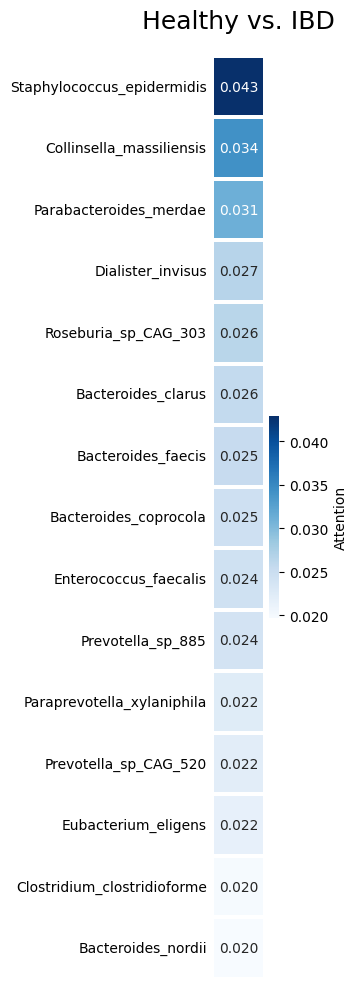

In [60]:
'''
Attention chart recreation according to their paper
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your provided data
data = top_10_species
# Clean up the species names (remove 's__') and extract values
species = [item[0].replace('s__', '') for item in data]
values = np.array([item[1] for item in data])

# Create a DataFrame for seaborn (heatmaps require 2D arrays)
df = pd.DataFrame(values, index=species, columns=['Attention'])

# Set up the matplotlib figure (tall and narrow)
fig, ax = plt.subplots(figsize=(3.5, 10))

# Draw the heatmap
sns.heatmap(
    df,
    annot=True,            # Write the data value in each cell
    fmt=".3f",             # Format to 3 decimal places to match the reference image
    cmap="Blues",          # The clear-to-blue color gradient
    linewidths=1.5,        # Add white grid lines between cells
    linecolor='white',
    cbar_kws={
        'label': 'Attention', 
        'shrink': 0.6    # Shrink the colorbar to match the image proportions
    }, 
    ax=ax
)

# Formatting to match the image's minimalist style
ax.set_title("Healthy vs. IBD", fontsize=18, pad=20)
ax.set_ylabel("")          # Remove the default 'species' y-label
ax.set_xticklabels([])     # Remove the 'Attention' x-label at the bottom of the column
ax.tick_params(axis='both', which='both', length=0) # Remove tick marks

# Ensure nothing gets cut off
plt.tight_layout()
plt.show()


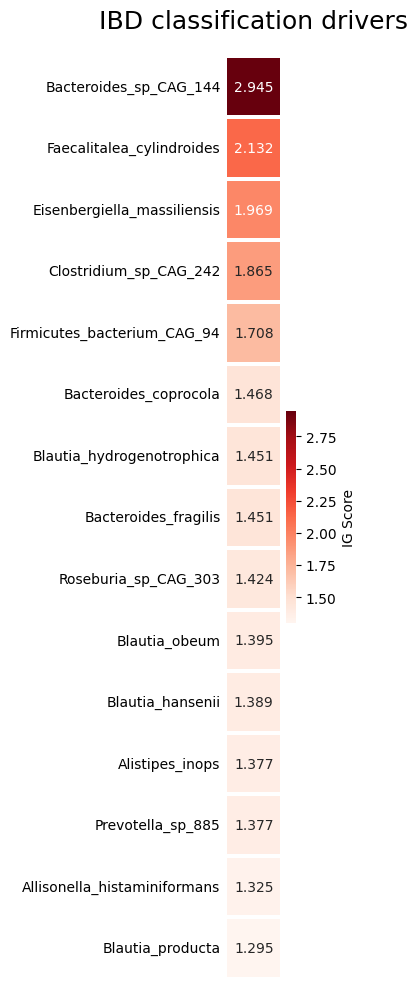

In [90]:
'''
Integrated Gradients: Pathogenic (IBD Drivers)
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your data is stored in a variable like this:
data = top_15_pos_species

# Clean up the species names (remove 's__') and extract values
species = [item[0].replace('s__', '') for item in data]
values = np.array([item[1] for item in data])

# Create a DataFrame for seaborn
df = pd.DataFrame(values, index=species, columns=['IG Score'])

# Set up the matplotlib figure (tall and narrow)
fig, ax = plt.subplots(figsize=(3.5, 10))

# Draw the heatmap
sns.heatmap(
    df,
    annot=True,            
    fmt=".3f",             
    cmap="Reds",           # Clear to Red gradient
    linewidths=1.5,        
    linecolor='white',
    cbar_kws={
        'label': 'IG Score', 
        'shrink': 0.6    
    }, 
    ax=ax
)

# Formatting
ax.set_title("IBD classification drivers", fontsize=18, pad=20)
ax.set_ylabel("")          
ax.set_xticklabels([])     
ax.tick_params(axis='both', which='both', length=0) 

# Ensure nothing gets cut off
plt.tight_layout()
plt.show()

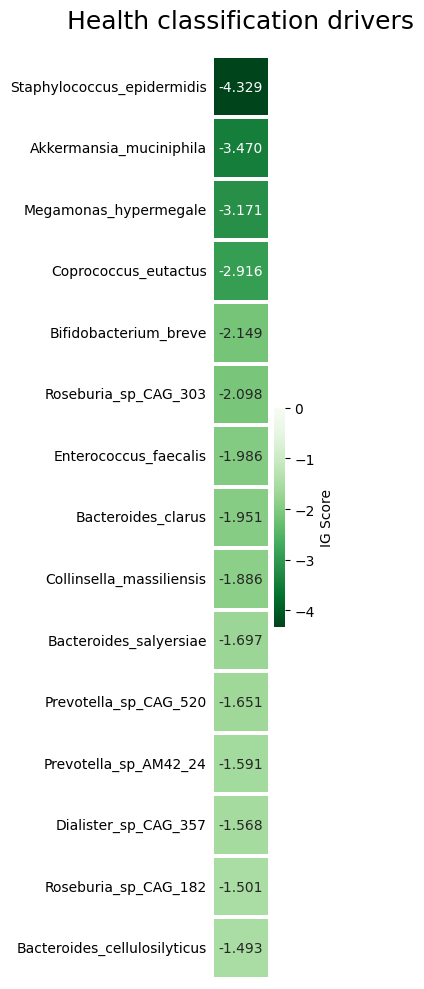

In [91]:
'''
Integrated Gradients: Protective (Health Drivers)
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your data is stored in a variable like this:
data = top_15_neg_species

# Clean up the species names (remove 's__') and extract values
species = [item[0].replace('s__', '') for item in data]
values = np.array([item[1] for item in data])

# Create a DataFrame for seaborn
df = pd.DataFrame(values, index=species, columns=['IG Score'])

# Set up the matplotlib figure (tall and narrow)
fig, ax = plt.subplots(figsize=(3.5, 10))

# Draw the heatmap
sns.heatmap(
    df,
    annot=True,            
    fmt=".3f",             
    cmap="Greens_r",       # Reversed Greens (Dark green for highly negative)
    vmax=0,                # Force 0 to be the clear/white baseline
    linewidths=1.5,        
    linecolor='white',
    cbar_kws={
        'label': 'IG Score', 
        'shrink': 0.6    
    }, 
    ax=ax
)

# Formatting
ax.set_title("Health classification drivers", fontsize=18, pad=20)
ax.set_ylabel("")          
ax.set_xticklabels([])     
ax.tick_params(axis='both', which='both', length=0) 

# Ensure nothing gets cut off
plt.tight_layout()
plt.show()

In [ ]:
'''
k-means on token vector color coded by True positive and True negative
'''

In [ ]:
'''
weights of species embedding k-means clustering show species names
'''

In [ ]:
#writeup!